# Youth Unemployment in Nigeria: Economic and Social Indicators Analysis (2000–2024)

## Step 1: Import libraries
**What this does:** Imports the tools used throughout the analysis. `pandas` handles tabular data, while `requests` is used to retrieve data from the World Bank API.

**Expected output:** No visible output; the libraries are loaded for later steps.

In [1]:
import pandas as pd
import requests

## Step 2: Define the indicators and prepare storage
**What this does:** Creates a dictionary containing the World Bank indicator codes and the names that will be used in the dataset. An empty list is also created to store each indicator dataset after retrieval.

**Indicators:** Youth unemployment, GDP growth, inflation, FDI, internet usage, and electricity access.

In [2]:
indicators = {
  "SL.UEM.1524.ZS": "Youth_Unemployment",
    "NY.GDP.MKTP.KD.ZG": "GDP_Growth",
    "FP.CPI.TOTL.ZG": "Inflation",
    "BX.KLT.DINV.WD.GD.ZS": "FDI",
    "IT.NET.USER.ZS": "Internet_usage",
    "EG.ELC.ACCS.ZS": "Electricity_access",
    
}

dataframes = []

## Step 3: Retrieve data from the World Bank API
**What this does:** Loops through each indicator, requests Nigeria data for 2000–2025, converts the returned observations into a DataFrame, keeps the year and value columns, and stores each indicator separately.

**Output:** Status code `200` indicates a successful API request. Each indicator is added to the `dataframes` list.

In [3]:
for code, name in indicators.items():
    print(f"Getting {name}...")
    
    url = f"https://api.worldbank.org/v2/country/NGA/indicator/{code}"
    
    response = requests.get(
        url,
        params={
            "date": "2000:2025",
            "format": "json",
            "per_page": 100
        },
        timeout=30
    )
    
    print(response.status_code)

    data = response.json()

    print(len(data))

    df_indicator = pd.DataFrame(data[1])

    df_indicator = df_indicator[["date", "value"]]

    df_indicator.columns = ["Year", name]

    dataframes.append(df_indicator)
    

  

Getting Youth_Unemployment...
200
2
Getting GDP_Growth...
200
2
Getting Inflation...
200
2
Getting FDI...
200
2
Getting Internet_usage...
200
2
Getting Electricity_access...
200
2


## Step 4: Verify the number of retrieved datasets
**What this does:** Checks how many indicator DataFrames were successfully created.

**Output:** The count should match the number of indicators requested.

In [4]:
print(len(dataframes))

6


## Step 5: Inspect the structure of each dataset
**What this does:** Prints the column names of every DataFrame to confirm that each contains `Year` and its corresponding indicator value.

**Why it matters:** This validates the data structure before merging.

In [5]:
for df in dataframes:
  print(df.columns.tolist())

['Year', 'Youth_Unemployment']
['Year', 'GDP_Growth']
['Year', 'Inflation']
['Year', 'FDI']
['Year', 'Internet_usage']
['Year', 'Electricity_access']


## Step 6: Merge all indicators into one dataset
**What this does:** Starts with the first indicator and merges the remaining indicator DataFrames using `Year` as the common key. An outer join is used to retain all available years before cleaning.

In [6]:
final_df = dataframes[0]
for df_indicator in dataframes[1:]:
  final_df = final_df.merge(
    df_indicator,
    on="Year",
    how="outer"
  )

## Step 7: Sort the combined dataset chronologically
**What this does:** Sorts the merged dataset by year and displays the first 10 records.

**Output:** A chronological preview of the combined economic and social indicators dataset.

In [7]:
final_df = final_df.sort_values("Year")
final_df.head(10)

,Year,Youth_Unemployment,GDP_Growth,Inflation,FDI,Internet_usage,Electricity_access
0,2000,7.571,5.015935,6.933292,1.648321,0.064081,43.2
1,2001,7.539,5.917685,18.873646,1.618616,0.089901,43.9
2,2002,7.219,15.329156,12.876579,1.971584,0.320462,44.6
3,2003,7.233,7.347195,14.031784,1.914621,0.558576,52.2
4,2004,7.228,9.250558,14.998034,1.380374,1.286138,46.1
5,2005,7.538,6.438517,17.863493,2.836294,3.549156,46.8
6,2006,7.687,6.059428,8.227437,2.035753,5.545036,47.6
7,2007,7.859,6.591130,5.386104,2.169195,6.770000,50.1
8,2008,7.921,6.764473,11.583055,2.413739,8.000000,50.3
9,2009,7.836,8.036925,12.537924,2.900249,9.300000,50.0


## Step 8: Check the dataset dimensions
**What this does:** Displays the number of rows and columns.

**Why it matters:** Confirms the size of the dataset after merging.

In [8]:
final_df.shape

(26, 7)

## Step 9: Check for missing values
**What this does:** Counts missing values in every column.

**Why it matters:** Missing data can affect correlation and regression analysis and should be addressed before modelling.

In [9]:
final_df.isna().sum()

Year                  0
Youth_Unemployment    0
GDP_Growth            0
Inflation             0
FDI                   0
Internet_usage        1
Electricity_access    1
dtype: int64

## Step 10: Inspect internet usage and electricity access
**What this does:** Displays these two indicators across all years for closer inspection.

**Why it matters:** These variables were specifically checked because unexpected values or missing observations could indicate an API or indicator-selection issue.

In [10]:
final_df[["Year","Internet_usage", "Electricity_access"]]

,Year,Internet_usage,Electricity_access
0,2000,0.064081,43.2
1,2001,0.089901,43.9
2,2002,0.320462,44.6
3,2003,0.558576,52.2
4,2004,1.286138,46.1
5,2005,3.549156,46.8
6,2006,5.545036,47.6
7,2007,6.770000,50.1
8,2008,8.000000,50.3
9,2009,9.300000,50.0


## Step 11: Identify years with missing internet or electricity data
**What this does:** Filters the dataset to show any records where either internet usage or electricity access is missing.

**Output:** An empty result would indicate no missing values for these two indicators.

In [11]:

final_df[final_df["Internet_usage"].isna() |final_df["Electricity_access"].isna()]

,Year,Youth_Unemployment,GDP_Growth,Inflation,FDI,Internet_usage,Electricity_access
25,2025,5.34,4.013362,23.010124,1.377386,NaN,NaN


## Step 12: Generate descriptive statistics
**What this does:** Calculates count, mean, standard deviation, minimum, quartiles, and maximum for the numeric indicators.

**Output:** A statistical summary that provides an initial understanding of the distribution and range of each variable.

In [12]:
#[final_df[final_df["Year"]>2024]]
import numpy as np

final_df.describe()

,Youth_Unemployment,GDP_Growth,Inflation,FDI,Internet_usage,Electricity_access
count,26.000000,26.000000,26.000000,26.000000,25.000000,25.000000
mean,7.855462,4.758004,14.280852,1.309059,17.392878,52.748000
std,1.464874,3.977687,6.084866,0.832890,13.835491,5.596287
min,5.088000,-6.368898,5.386104,-0.028873,0.064081,43.200000
25%,7.309250,2.818496,10.968708,0.626082,5.545036,48.000000
50%,7.847500,5.161929,13.061301,1.378880,16.100000,53.000000
75%,8.353750,6.651284,16.840201,1.957343,27.743700,55.900000
max,10.842000,15.329156,33.241659,2.900249,41.211399,62.500000


## Step 13: Check data types
**What this does:** Displays the data type of each column.

**Why it matters:** The variables used for numerical analysis should have appropriate numeric data types.

In [13]:
final_df.dtypes

Year                   object
Youth_Unemployment    float64
GDP_Growth            float64
Inflation             float64
FDI                   float64
Internet_usage        float64
Electricity_access    float64
dtype: object

## Step 14: Remove the incomplete 2025 observation
**What this does:** Creates `clean_df` by excluding 2025, which was not complete for the analysis.

**Output:** The cleaned dataset containing the years used for the final analysis.

In [14]:
clean_df = final_df[final_df["Year"]!="2025"]
clean_df

,Year,Youth_Unemployment,GDP_Growth,Inflation,FDI,Internet_usage,Electricity_access
0,2000,7.571,5.015935,6.933292,1.648321,0.064081,43.2
1,2001,7.539,5.917685,18.873646,1.618616,0.089901,43.9
2,2002,7.219,15.329156,12.876579,1.971584,0.320462,44.6
3,2003,7.233,7.347195,14.031784,1.914621,0.558576,52.2
4,2004,7.228,9.250558,14.998034,1.380374,1.286138,46.1
5,2005,7.538,6.438517,17.863493,2.836294,3.549156,46.8
6,2006,7.687,6.059428,8.227437,2.035753,5.545036,47.6
7,2007,7.859,6.591130,5.386104,2.169195,6.770000,50.1
8,2008,7.921,6.764473,11.583055,2.413739,8.000000,50.3
9,2009,7.836,8.036925,12.537924,2.900249,9.300000,50.0


## Step 15: Confirm there are no missing values after cleaning
**What this does:** Rechecks missing values in `clean_df`.

**Expected output:** Zero missing values across the final analytical dataset.

In [15]:
clean_df.isna().sum()

Year                  0
Youth_Unemployment    0
GDP_Growth            0
Inflation             0
FDI                   0
Internet_usage        0
Electricity_access    0
dtype: int64

## Step 16: Confirm the final dataset size
**What this does:** Displays the dimensions of `clean_df`.

**Output:** This confirms the number of annual observations and variables used in the analysis.

In [16]:
clean_df.shape

(25, 7)

## Step 17: Recheck data types in the cleaned dataset
**What this does:** Confirms that the cleaned variables have suitable data types before analysis.

In [17]:
clean_df.dtypes

Year                   object
Youth_Unemployment    float64
GDP_Growth            float64
Inflation             float64
FDI                   float64
Internet_usage        float64
Electricity_access    float64
dtype: object

## Step 18: Convert Year to an integer
**What this does:** Changes `Year` from an object/string type to an integer.

**Why it matters:** This ensures years can be sorted and used correctly in time-based analysis and visualizations.

In [18]:
clean_df["Year"] = clean_df["Year"].astype(int)

C:\Users\potte\AppData\Local\Temp\ipykernel_10288\944525611.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["Year"] = clean_df["Year"].astype(int)


## Step 19: Export the cleaned dataset
**What this does:** Saves the final cleaned dataset as a CSV file for use in Power BI and other tools.

**Output:** A reusable dataset containing the cleaned indicators.

In [19]:
clean_df.to_csv(r"C:\Users\potte\Desktop\Trial\Economic_social_indicators.csv")

## Step 20: Review descriptive statistics for the final dataset
**What this does:** Generates summary statistics after cleaning, providing the final statistical overview used for the project.

In [20]:
clean_df.describe()

,Year,Youth_Unemployment,GDP_Growth,Inflation,FDI,Internet_usage,Electricity_access
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,2012.000000,7.956080,4.787790,13.931681,1.306326,17.392878,52.748000
std,7.359801,1.400383,4.056749,5.938545,0.849945,13.835491,5.596287
min,2000.000000,5.088000,-6.368898,5.386104,-0.028873,0.064081,43.200000
25%,2006.000000,7.538000,2.652693,10.826137,0.621502,5.545036,48.000000
50%,2012.000000,7.859000,5.307924,12.876579,1.380374,16.100000,53.000000
75%,2018.000000,8.457000,6.671335,16.502266,1.971584,27.743700,55.900000
max,2024.000000,10.842000,15.329156,33.241659,2.900249,41.211399,62.500000


## Step 21: Identify the highest youth unemployment observation
**What this does:** Finds the year with the maximum youth unemployment value and displays the complete record.

**Why it matters:** Helps identify a notable peak in the series for further interpretation.

In [21]:
clean_df.loc[clean_df["Youth_Unemployment"].idxmax()]

Year                  2020.000000
Youth_Unemployment      10.842000
GDP_Growth              -6.368898
Inflation               13.246023
FDI                      0.398485
Internet_usage          31.888800
Electricity_access      55.400000
Name: 20, dtype: float64

## Step 22: Identify the lowest youth unemployment observation
**What this does:** Finds the year with the minimum youth unemployment value and displays the complete record.

In [22]:
clean_df.loc[clean_df["Youth_Unemployment"].idxmin()]

Year                  2024.000000
Youth_Unemployment       5.088000
GDP_Growth               4.071067
Inflation               33.241659
FDI                      0.639824
Internet_usage          41.211399
Electricity_access      62.500000
Name: 24, dtype: float64

## Step 23: Examine correlations with youth unemployment
**What this does:** Removes `Year`, calculates Pearson correlations, and sorts the relationships with youth unemployment.

**How to interpret:** Values closer to +1 indicate positive linear association, values closer to −1 indicate negative linear association, and values near 0 indicate little linear relationship. Correlation does not establish causation.

In [23]:
analysis_df = clean_df.drop(columns=["Year"])
correlation = analysis_df.corr()
print(correlation["Youth_Unemployment"].sort_values(ascending=False))

Youth_Unemployment    1.000000
Internet_usage        0.057642
Electricity_access   -0.023275
FDI                  -0.197309
Inflation            -0.488647
GDP_Growth           -0.532166
Name: Youth_Unemployment, dtype: float64


## Step 24: Visualize GDP growth vs youth unemployment
**What this does:** Creates a scatter plot showing the relationship between GDP growth and youth unemployment across the study period.

**Output:** Each point represents one year. The plot helps visually assess the direction and strength of the relationship.

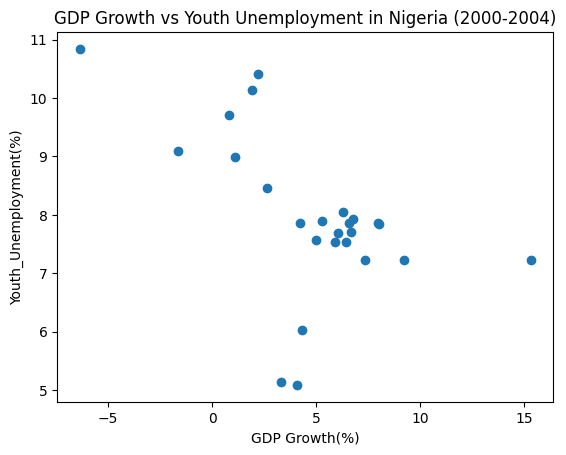

In [24]:
import matplotlib.pyplot as plt

plt.scatter(
  clean_df["GDP_Growth"],
  clean_df["Youth_Unemployment"]
)

plt.xlabel("GDP Growth(%)")
plt.ylabel("Youth_Unemployment(%)")
plt.title("GDP Growth vs Youth Unemployment in Nigeria (2000-2004)")

plt.show()

## Step 25: Add a linear trend line
**What this does:** Uses `numpy.polyfit()` to calculate a best-fit straight line and overlays it on the scatter plot.

**Why it matters:** The trend line makes the overall linear direction easier to observe.

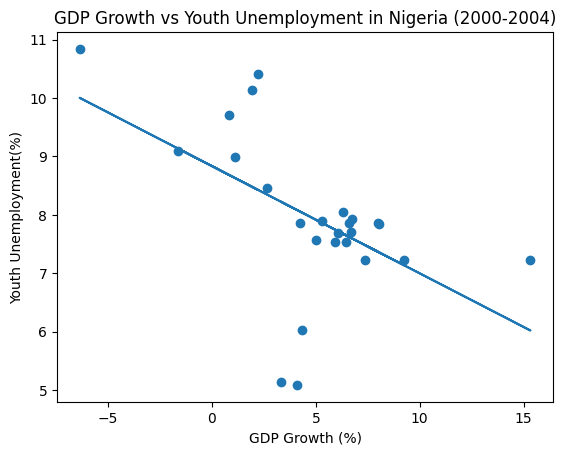

In [25]:
import numpy as np

x = clean_df["GDP_Growth"]
y = clean_df["Youth_Unemployment"]

m,b = np.polyfit(x,y,1)

plt.scatter(x,y)
plt.plot(x, m*x + b)

plt.xlabel("GDP Growth (%)")
plt.ylabel("Youth Unemployment(%)")
plt.title("GDP Growth vs Youth Unemployment in Nigeria (2000-2004)")

plt.show()

## Step 26: Investigate years with negative GDP growth
**What this does:** Filters the dataset to display years where GDP growth was below zero alongside youth unemployment.

**Why it matters:** This helps examine economic contraction periods and potential outliers.

In [26]:
clean_df[clean_df["GDP_Growth"]<0][["Year", "GDP_Growth", "Youth_Unemployment"]]



,Year,GDP_Growth,Youth_Unemployment
16,2016,-1.616869,9.100
20,2020,-6.368898,10.842


## Step 27: Investigate unusually high GDP growth
**What this does:** Displays years where GDP growth exceeded 10%.

**Why it matters:** These observations can help identify unusually strong economic-growth periods that may influence the overall relationship.

In [27]:
clean_df[clean_df["GDP_Growth"] > 10][["Year", "GDP_Growth", "Youth_Unemployment"]]

,Year,GDP_Growth,Youth_Unemployment
2,2002,15.329156,7.219


## Step 28: Test the influence of 2020 on the GDP correlation
**What this does:** Calculates the GDP growth–youth unemployment correlation with all observations and then recalculates it after removing 2020.

**Why it matters:** 2020 was an unusual economic period, so this checks whether it disproportionately influences the observed relationship.

In [28]:
correlation_all = clean_df["GDP_Growth"].corr(clean_df["Youth_Unemployment"])
print("With 2020:", correlation_all)

without_2020 = clean_df[clean_df["Year"] != 2020]

correlation_without_2020 = without_2020["GDP_Growth"].corr(without_2020["Youth_Unemployment"])
print("Without 2020:", correlation_without_2020)

With 2020: -0.5321663352866358
Without 2020: -0.3866192514955874


## Step 29: Recalculate the broader correlation results without 2020
**What this does:** Removes 2020 and calculates correlations among the remaining indicators.

**Output:** A comparison that helps assess the sensitivity of the relationships to that unusual year.

In [29]:
without_2020 = clean_df[clean_df["Year"] != 2020]

correlations_without_2020 =without_2020 .drop(columns=["Year"]).corr()["Youth_Unemployment"].sort_values(ascending=False)

print(correlations_without_2020)

Youth_Unemployment    1.000000
Internet_usage       -0.040927
Electricity_access   -0.073061
FDI                  -0.115584
GDP_Growth           -0.386619
Inflation            -0.529769
Name: Youth_Unemployment, dtype: float64


## Step 30: Create a correlation heatmap
**What this does:** Calculates correlations among all numeric indicators and visualizes them as a matrix. Exact correlation values are written inside each cell.

**How to read it:** Values near +1 are strong positive relationships, values near −1 are strong negative relationships, and values near 0 indicate weak linear relationships.

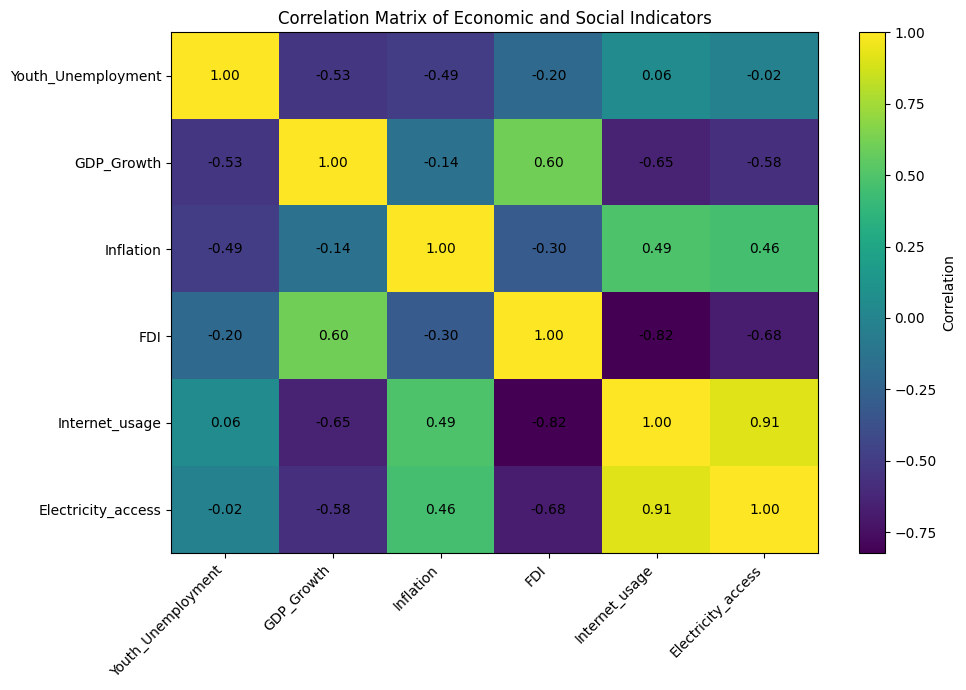

In [30]:
corr = clean_df.drop(columns=["Year"]).corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label="Correlation")
plt.title("Correlation Matrix of Economic and Social Indicators")

# Add values inside the boxes
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## Research Question
### Can GDP growth, inflation, FDI, internet usage, and electricity access collectively explain variation in youth unemployment in Nigeria?

The following sections use multiple linear regression and diagnostic tests to investigate this question.

### Can GDP growth, inflation, FDI, internet usage, and electricity access collectively explain variation in youth unemployment in Nigeria?

## Step 31: Define the regression variables
**What this does:** Sets youth unemployment as the dependent variable (`y`) and the five selected economic and social indicators as independent variables (`x`).

**Purpose:** To test their collective statistical association with youth unemployment.

In [31]:
x = clean_df[["GDP_Growth", "Inflation", "FDI", "Internet_usage", "Electricity_access"]]
y = clean_df["Youth_Unemployment"]

## Step 32: Add the regression constant
**What this does:** Adds an intercept term to the independent-variable matrix.

**Why it matters:** The constant allows the OLS model to estimate the baseline level of youth unemployment when the predictors are zero.

In [32]:
import statsmodels.api as sm
x = sm.add_constant(x)

## Step 33: Fit the initial OLS regression model
**What this does:** Fits an Ordinary Least Squares regression using all five predictors and prints the full statistical summary.

**Key output to review:** R-squared, adjusted R-squared, coefficients, p-values, confidence intervals, and diagnostic statistics.

In [33]:
model = sm.OLS(y,x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Youth_Unemployment   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     6.714
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           0.000927
Time:                        17:40:49   Log-Likelihood:                -30.661
No. Observations:                  25   AIC:                             73.32
Df Residuals:                      19   BIC:                             80.64
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 15.0411      4

## Step 34: Check multicollinearity using VIF
**What this does:** Calculates the Variance Inflation Factor for each predictor.

**How to interpret:** Higher VIF values indicate stronger multicollinearity. This helps identify predictors that may be strongly related to one another and make coefficient estimates unstable.

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = clean_df[["GDP_Growth","Inflation","FDI","Internet_usage","Electricity_access"]]
vif = pd.DataFrame()

vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i)
   for i in range(X_vif.shape[1])]
print(vif)

             Variable        VIF
0          GDP_Growth   4.556581
1           Inflation   9.820876
2                 FDI  12.439227
3      Internet_usage  19.124248
4  Electricity_access  39.741971


## Step 35: Inspect correlations among the predictors
**What this does:** Calculates the correlation matrix for the independent variables only.

**Why it matters:** Strong relationships between predictors provide additional evidence of potential multicollinearity.

In [35]:
predictors = clean_df[["GDP_Growth","Inflation","FDI","Internet_usage","Electricity_access"]]
predictors.corr()

,GDP_Growth,Inflation,FDI,Internet_usage,Electricity_access
GDP_Growth,1.000000,-0.142805,0.604269,-0.646021,-0.575069
Inflation,-0.142805,1.000000,-0.299135,0.491523,0.461959
FDI,0.604269,-0.299135,1.000000,-0.823093,-0.680466
Internet_usage,-0.646021,0.491523,-0.823093,1.000000,0.914258
Electricity_access,-0.575069,0.461959,-0.680466,0.914258,1.000000


## Step 36: Visualize predictor correlations
**What this does:** Creates a heatmap of correlations among the independent variables, with values displayed in each cell.

**Purpose:** To visually identify highly correlated predictors before refining the regression model.

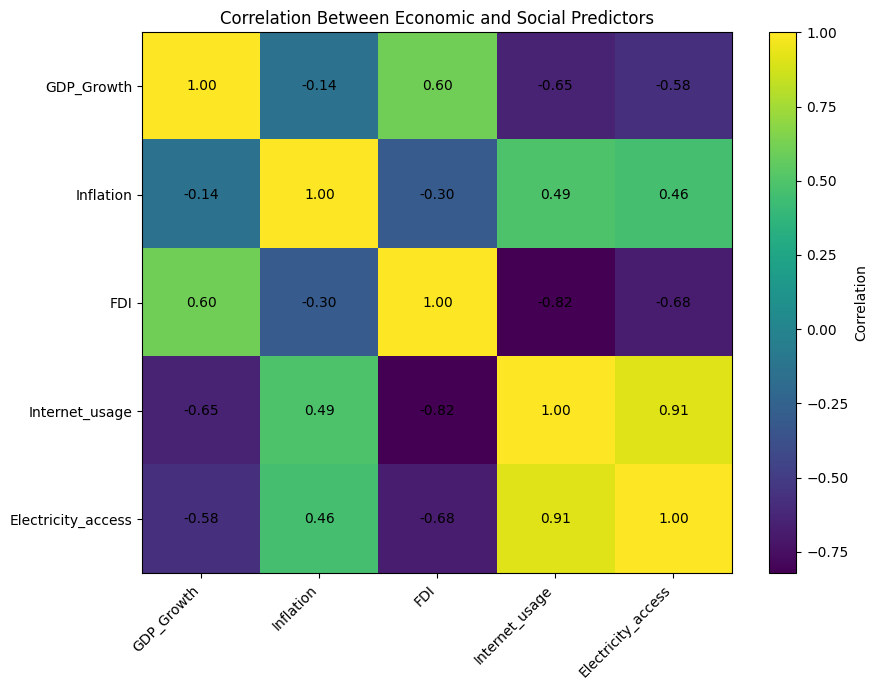

In [36]:
corr = predictors.corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.xticks(
range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label="Correlation")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Between Economic and Social Predictors")

plt.tight_layout()
plt.show()

## Step 37: Fit a refined model without electricity access
**What this does:** Runs an alternative OLS model using GDP growth, inflation, FDI, and internet usage.

**Purpose:** To compare model performance and multicollinearity after removing one highly correlated predictor.

In [37]:

X2 = clean_df[["GDP_Growth","Inflation","FDI","Internet_usage"]]

y = clean_df["Youth_Unemployment"]

X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:     Youth_Unemployment   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     8.251
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           0.000423
Time:                        17:40:49   Log-Likelihood:                -31.199
No. Observations:                  25   AIC:                             72.40
Df Residuals:                      20   BIC:                             78.49
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             11.5012      0.999     11.

## Step 38: Fit the alternative final candidate model
**What this does:** Runs an OLS model using GDP growth, inflation, FDI, and electricity access.

**Output:** This model is subsequently evaluated with VIF and diagnostic tests.

In [38]:
X3 = clean_df[["GDP_Growth","Inflation","FDI","Electricity_access"]]

X3 = sm.add_constant(X3)

model3 = sm.OLS(y, X3).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:     Youth_Unemployment   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     8.798
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           0.000288
Time:                        17:40:49   Log-Likelihood:                -30.693
No. Observations:                  25   AIC:                             71.39
Df Residuals:                      20   BIC:                             77.48
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 14.4513      2

## Step 39: Recheck VIF for the selected predictors
**What this does:** Calculates VIF values for the predictors in `model3`.

**Purpose:** To assess whether multicollinearity improved after removing internet usage.

In [39]:
X3_vif = clean_df[["GDP_Growth","Inflation","FDI","Electricity_access"]]

vif3 = pd.DataFrame()

vif3["Variable"] = X3_vif.columns
vif3["VIF"] = [variance_inflation_factor(X3_vif.values, i)
    for i in range(X3_vif.shape[1])]

print(vif3)

             Variable        VIF
0          GDP_Growth   3.864183
1           Inflation   8.412954
2                 FDI   5.206179
3  Electricity_access  11.299738


## Step 40: Examine the residuals vs fitted values
**What this does:** Plots model residuals against fitted values with a horizontal zero reference line.

**How to interpret:** A roughly random spread around zero supports a reasonable linear-model specification. Clear patterns may indicate potential issues such as non-linearity or unequal variance.

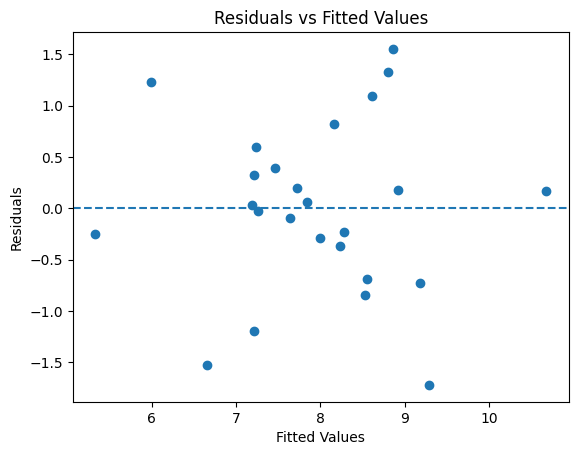

In [41]:
residuals = model3.resid

plt.scatter(model3.fittedvalues, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

## Step 41: Test for heteroscedasticity
**What this does:** Performs the Breusch–Pagan test on the residuals.

**How to interpret:** A small p-value provides evidence against constant residual variance. The output includes LM and F versions of the test.

In [42]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    model3.resid,
    model3.model.exog
)

labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(5.730951799014234), 'LM p-value': np.float64(0.22016212008974348), 'F Statistic': np.float64(1.487087410659196), 'F p-value': np.float64(0.24361980663565513)}


## Step 42: Check residual autocorrelation with Durbin–Watson
**What this does:** Calculates the Durbin–Watson statistic for the regression residuals.

**General interpretation:** A value around 2 suggests little first-order autocorrelation; values substantially below or above 2 can indicate positive or negative autocorrelation respectively.

In [43]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(model3.resid)

print("Durbin-Watson:", dw)

Durbin-Watson: 1.1088024864100876


## Step 43: Test for serial correlation
**What this does:** Performs the Breusch–Godfrey test using one lag.

**How to interpret:** The p-values help assess whether there is evidence of autocorrelation in the model residuals.

In [44]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

bg_test = acorr_breusch_godfrey(model3, nlags=1)

labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

print(dict(zip(labels, bg_test)))

{'LM Statistic': np.float64(4.122288526514145), 'LM p-value': np.float64(0.04232179056496123), 'F Statistic': 3.751535799469092, 'F p-value': 0.06777307489628694}


## Step 44: Estimate HAC-robust regression results
**What this does:** Recalculates the standard errors using HAC (heteroscedasticity and autocorrelation consistent) estimation with one lag.

**Important:** HAC changes the standard errors and inference while retaining the same fitted regression specification. The output is used to provide more robust statistical inference when residual variance and autocorrelation concerns are present.

**Key results:** Review coefficients, robust standard errors, p-values, confidence intervals, and overall model fit.

In [45]:
model3_hac = model3.get_robustcov_results(
    cov_type="HAC",
    maxlags=1
)

print(model3_hac.summary())

                            OLS Regression Results                            
Dep. Variable:     Youth_Unemployment   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     9.124
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           0.000231
Time:                        17:52:15   Log-Likelihood:                -30.693
No. Observations:                  25   AIC:                             71.39
Df Residuals:                      20   BIC:                             77.48
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 14.4513      2